<a href="https://colab.research.google.com/github/rebecapaes/MVP-posgrad-machine-learning/blob/main/MVP_MachineLearning_RebecaPaes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Rebeca Esteves de Lima Paes

**Matrícula:** 405202502290

**Data:** 05/07/2026

**Dataset:** Nordic textile anatomy database: Composition of garments available in the nordic retail mass market and post-consumer textile waste market

[link do artigo](https://doi.org/10.1016/j.dib.2025.111512)  
[link do dataset](https://doi.org/10.11583/DTU.24581700)


**Tipo de problema:** Regressão  


# 1. O problema

## 1.1. Descrição do Problema
Tomada de decisão do melhor caminho para reciclagem ou reuso de peças na gestão de resíduos texteis, visando a melhora do impacto ambiental no setor.
Atualmente existem dois principais caminhos mais utilizados para o reuso de peças descartadas:
1. Reciclagem mecânica (desfibramento):\
Processo em que o material passa por maquinário de grande escala, e é triturado e processado gerando novos fios e em seguida novos tecidos.
Nesse processo, a peça nao pode ter aviamentos (o que pode resultar em defeitos no maquinário), a presença de entretela e forros pode dificultar o processamento pela máquina e quanto mais fibras misturadas pior será a qualidade do novo tecido.
2. Upcycling:\
Processo artesanal que transforma a peça original em uma nova, gerando novas possibilidades de uso e novo valor estético.


**Esclarecimento de termos técnicos**
- Aviamentos: Botões, zipers, fechos
- Entretela: Material usado em baixo do tecido principal(geralmente colado nele) para dar mais estrutura a peça


## 1.2. Objetivo do MVP
Criar uma ferramenta através de um modelo de machine learning que indique a viabilidade de uma peça de descarte textil ser reciclada via reciclagem mecânica.\
Entender antecipadamente as limitações da reciclagem mecânica ajuda a automatizar processos de triagem, poupando tempo e evitando desperdícios desnecessários.

## 1.3. Tipo de Problema
Regressão Supervisionada
O objetivo é prever um valor numérico contínuo (o score de reciclabilidade de 0 a 1). O valor contínuo permite ao usuário do modelo ter uma ferramenta para ajudar a escolher o caminho e não tomar a decisão por ele.\
O score de reciclabilidade não é booleano, cada empresa tem um processo e para umas pode ser menos custoso ou não retirar os aviamentos por exemplo.

Além disso, existem outras variáveis (ex:tingimento, condições da peça, prazo, etc) que não estão listadas no dataset mas que podem interferir nessa escolha.  

## 1.4. Premissas, hipóteses e critérios de sucesso
1. **Hipótese 1:**\
Um modelo de Machine Learning é capaz de aprender o padrão de reciclabilidade a partir de parâmetros observados na peça - composição de fibra, presença e quantidade de aviamentos (findings) e número de camadas (layers) - gerando um conhecimento para novas peças sem a necessidade de um cálculo manual recorrente.

2. **Hipótese 2:**\
No caso de peças sem etiqueta, o modelo conseguiria prever corretamente o score de reciclabilidade apenas com características visuais?

**Premissas assumidas:**
- A fórmula de composição do score, baseada na literatura (Logan et al., 2025; Fatalla, Gasi & Sanches, 2026; Guia Greenhub/ABIT, 2024), reflete bem as dificuldades de reciclagem mecânica de cada peça.
- Suposição que valores como NFD e NA para fibras significam a ausencia de mais um fibra, e não um erro de coleta dos dados

**Critérios de sucesso:**
- O modelo deve superar significativamente o baseline (Regressão Linear) e mostrar boa capacidade de generalização (R² elevado no conjunto de teste).
- O experimento complementar (score estimado apenas por atributos visuais) deve evidenciar a relevância da informação de composição de fibra, validando a abordagem adotada.

# 2.Ambiente, bibliotecas e reprodutibilidade

### Importação das bibliotecas e datasets

In [1]:
# instalação do xgboost
!pip install xgboost --quiet

# importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb

# importação das classes necessárias
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# definição de seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Seed:", SEED)

Seed: 42


In [3]:
# Versões das bibliotecas
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)

pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
scikit-learn: 1.6.1
xgboost: 3.3.0


In [4]:
# criação da função auxiliar para criar o score
def calcular_score(amostra):
    score = 1

    ids_fibra = [amostra[col] for col in colunas_fibra_id if amostra[col] != 0]
    qtd_fibras = len(ids_fibra)
    if qtd_fibras > 1:
        score -= 0.09 * (qtd_fibras - 1)

    tem_sintetica = any(fb_id in fibras_sinteticas for fb_id in ids_fibra)
    if tem_sintetica:
        score -= 0.09

    score -= 0.0125 * amostra["total_findings"]

    if amostra["layers"] == "multi-layered":
        score -= 0.15

    return max(0.0, min(1.0, score))

# 3. Seleção e carga dos dados

## 3.1. Fonte dos dados  

**Dataset:** Nordic textile anatomy database: Composition of garments available in the nordic retail mass market and post-consumer textile waste market
Possui informações sobre a composição têxtil de mais de 5 mil peças de vestuário, coletadas em duas campanhas realizadas na região nórdica em 2022:

- **RMM (Retail Mass Market)** — 4.495 peças encontradas em varejistas do mercado de massa em Copenhague, durante a primavera/verão de 2022. Representa têxteis pré-consumo(ou pós indústria) disponíveis no varejo.

- **PCTWM (Post-Consumer Textile Waste Market)** — 1.248 peças encontradas em fardos de resíduos têxteis pós-consumo na instalação de triagem SIPTEX, em Malmö, durante o inverno de 2022. Representa têxteis descartados, já em processo de triagem para reciclagem.

[link do artigo](https://doi.org/10.1016/j.dib.2025.111512)  
[link do dataset](https://doi.org/10.11583/DTU.24581700)

**Por que este dataset ?**
Seguindo o tema "redução do impacto ambiental na indústria textil" do meu primeiro MVP, esses dados

Por que esse dataset foi escolhido
Seguindo o foco em trabalhar com melhorias do impacto ambiental da industria textil iniciado no primeiro MVP, esses dados possuem uma granularidade boa de informações e uma ótima confiabilidade já que possui um artigo escrito baseado na coleta desses dados.

## 3.2. Carga dos dados  

In [5]:
# Carregamento dataset industrial (RMM - Retail Mass Market)
url_rmm = 'https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-machine-learning/refs/heads/main/Nordic_TextileAnatomy_DB_RMM_DK.csv'

rmm = pd.read_csv(url_rmm, header=0)

type(rmm)

pandas.core.frame.DataFrame

In [6]:
# Carregamento dataset pós consumo (PCTWM - Post Consumer Textiles Waste Market)
url_pctwm = 'https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-machine-learning/refs/heads/main/Nordic_TextileAnatomy_DB_PCTWM_SE.csv'

pctwm = pd.read_csv(url_pctwm, header=0)

type(pctwm)

pandas.core.frame.DataFrame

### Criação dataset final

Criação de um novo dataset (df_todos) com apenas os dados importantes para o meu problema e coluna target adicionada.

#### Organização dos datasets ainda separados

Realização de cópias sem alterar os originais gerando df_rmm e df_pctwm.


In [7]:
# seleciona apenas as primeiras 18 colunas
# mostrar 10 primeiras linhas
df_rmm = rmm.iloc[:, :18].copy()
df_rmm.head()

,Category,Fibre 1 Number,Fibre 1,Fibre 1 % Range,Fiber 2 Number,Fibre 2,Fibre 2 % Range,Fibre 3 Number,Fibre 3,Fibre 3 % Range,Fibre 4 Number,Fibre 4,Fibre 4 % Range,Fibre 5 Number,Fibre 5,Fibre 5 % Range,Total Findings,Layers
0,Dresses and skirts,25.0,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35.0,Polyester,<10%,37.0,Polypropylene,<10%,NaN,NaN,NaN,1.0,0.0
1,Dresses and skirts,5.0,Cotton,51-60%,25,Viscose,10-20%,35.0,Polyester,10-20%,30.0,Polyamide/nylon,10-20%,NaN,NaN,NaN,2.0,0.0
2,Dresses and skirts,26.0,Acrylic,71-80%,35,Polyester,10-20%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
3,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,31-40%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
4,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,41-50%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0


In [8]:
# exclusão de colunas com metadados de identificação e triagem
excluir_colunas = [0,1, 2, 3, 4, 6, 7, 8, 25]

# lista com as 32 primeiras linhas menos as da lista "excluir_colunas"
colunas_final = [
    i for i in range(31)
    if i not in excluir_colunas
]

df_pctwm = pctwm.iloc[:, colunas_final].copy()
df_pctwm.head(10)

,Article Category General,Fibre 1 Number,Fibre 1,Fibre 1 % Range,Fiber 2 Number,Fibre 2,Fibre 2 % Range,Fibre 3 Number,Fibre 3,Fibre 3 % Range,...,Fibre 4 % Range,Fibre 5 Number,Fibre 5,Fibre 5 % Range,Layers,Findings and/or trims?,Total Metal Finding Types,Total plastic Finding Types,Total Fabric Finding Types,Total Other Finding Types
0,Accessories,26,Acrylic,100%,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,mono-layered,1.0,0.0,1.0,0.0,0.0
1,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
2,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
3,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
4,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
5,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
6,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
7,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
8,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
9,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0


#### Padronização dos nomes das colunas

Criando a equivalência dos nomes das colunas, e adicionando underline entre os nomes para melhor uso durante o código.

In [9]:
df_rmm = df_rmm.rename(columns= {
    "Fibre 1 Number": "fb1_id",
    "Fibre 1": "fb1_name",
    "Fibre 1 % Range": "fb1_percentage",
    "Fiber 2 Number": "fb2_id",
    "Fibre 2": "fb2_name",
    "Fibre 2 % Range": "fb2_percentage",
    "Fibre 3 Number": "fb3_id",
    "Fibre 3": "fb3_name",
    "Fibre 3 % Range": "fb3_percentage",
    "Fibre 4 Number": "fb4_id",
    "Fibre 4": "fb4_name",
    "Fibre 4 % Range": "fb4_percentage",
    "Fibre 5 Number": "fb5_id",
    "Fibre 5": "fb5_name",
    "Fibre 5 % Range": "fb5_percentage",
    "Layers": "layers",
    "Total Findings": "total_findings"
})

df_rmm.head ()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers
0,Dresses and skirts,25.0,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35.0,Polyester,<10%,37.0,Polypropylene,<10%,NaN,NaN,NaN,1.0,0.0
1,Dresses and skirts,5.0,Cotton,51-60%,25,Viscose,10-20%,35.0,Polyester,10-20%,30.0,Polyamide/nylon,10-20%,NaN,NaN,NaN,2.0,0.0
2,Dresses and skirts,26.0,Acrylic,71-80%,35,Polyester,10-20%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
3,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,31-40%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
4,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,41-50%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0


In [10]:
df_pctwm = df_pctwm.rename(columns= {
    "Article Category General": "Category",
    "Fibre 1 Number": "fb1_id",
    "Fibre 1": "fb1_name",
    "Fibre 1 % Range": "fb1_percentage",
    "Fiber 2 Number": "fb2_id",
    "Fibre 2": "fb2_name",
    "Fibre 2 % Range": "fb2_percentage",
    "Fibre 3 Number": "fb3_id",
    "Fibre 3": "fb3_name",
    "Fibre 3 % Range": "fb3_percentage",
    "Fibre 4 Number": "fb4_id",
    "Fibre 4": "fb4_name",
    "Fibre 4 % Range": "fb4_percentage",
    "Fibre 5 Number": "fb5_id",
    "Fibre 5": "fb5_name",
    "Fibre 5 % Range": "fb5_percentage",
    "Layers": "layers"
})

df_pctwm["layers"] = df_pctwm["layers"].fillna("mono-layered")

df_pctwm.head ()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,...,fb4_percentage,fb5_id,fb5_name,fb5_percentage,layers,Findings and/or trims?,Total Metal Finding Types,Total plastic Finding Types,Total Fabric Finding Types,Total Other Finding Types
0,Accessories,26,Acrylic,100%,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,mono-layered,1.0,0.0,1.0,0.0,0.0
1,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
2,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
3,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0
4,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0


#### Cálculo da coluna total_findings no dataset pós consumo

Essa coluna só existia nos dados de amostras pós processo industrial. No dataset pós consumo esses dados estavam divididos em tipos de aviamentos.

In [11]:
for i, col in enumerate(df_pctwm.columns):
    print(i, col)

0 Category
1 fb1_id
2 fb1_name
3 fb1_percentage
4 fb2_id
5 fb2_name
6 fb2_percentage
7 fb3_id
8 fb3_name
9 fb3_percentage
10 fb4_id
11 fb4_name
12 fb4_percentage
13 fb5_id
14 fb5_name
15 fb5_percentage
16 layers
17 Findings and/or trims?
18 Total Metal Finding Types
19 Total plastic Finding Types
20 Total Fabric Finding Types
21 Total Other Finding Types


In [12]:
df_pctwm["total_findings"] = (
    df_pctwm.iloc[:, 18] +
    df_pctwm.iloc[:, 19] +
    df_pctwm.iloc[:, 20] +
    df_pctwm.iloc[:, 21]
).fillna(0).astype(int)

df_pctwm.head ()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,...,fb5_id,fb5_name,fb5_percentage,layers,Findings and/or trims?,Total Metal Finding Types,Total plastic Finding Types,Total Fabric Finding Types,Total Other Finding Types,total_findings
0,Accessories,26,Acrylic,100%,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,mono-layered,1.0,0.0,1.0,0.0,0.0,1
1,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0
2,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0
3,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0
4,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0


#### Padronização dos valores da coluna layers

Optei por manter todos como mono-layered/multi-layered nesse momento para melhor entendimento no olhar humano. Deixando em códigos binários apenas na fase de construção e implementação do modelo.

In [13]:
# padroniza os valores na coluna layers em ambos datasets

df_rmm["layers"] = df_rmm["layers"].replace({
    0: "mono-layered",
    1: "multi-layered"
})

df_rmm["layers"] = df_rmm["layers"].fillna("mono-layered")

df_rmm.head()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers
0,Dresses and skirts,25.0,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35.0,Polyester,<10%,37.0,Polypropylene,<10%,NaN,NaN,NaN,1.0,mono-layered
1,Dresses and skirts,5.0,Cotton,51-60%,25,Viscose,10-20%,35.0,Polyester,10-20%,30.0,Polyamide/nylon,10-20%,NaN,NaN,NaN,2.0,mono-layered
2,Dresses and skirts,26.0,Acrylic,71-80%,35,Polyester,10-20%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered
3,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,31-40%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,multi-layered
4,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,41-50%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,multi-layered


#### Criação dos IDs
Cada amostra terá um identificador único, viabilizando separação dos conjuntos para investigações específicas e filtro de peças só com informação visual para o segundo experimento.

In [14]:
df_rmm["ID"] = [f"R{i:04d}" for i in range(1, len(df_rmm)+1)]

df_rmm.head()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers,ID
0,Dresses and skirts,25.0,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35.0,Polyester,<10%,37.0,Polypropylene,<10%,NaN,NaN,NaN,1.0,mono-layered,R0001
1,Dresses and skirts,5.0,Cotton,51-60%,25,Viscose,10-20%,35.0,Polyester,10-20%,30.0,Polyamide/nylon,10-20%,NaN,NaN,NaN,2.0,mono-layered,R0002
2,Dresses and skirts,26.0,Acrylic,71-80%,35,Polyester,10-20%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered,R0003
3,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,31-40%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,multi-layered,R0004
4,Dresses and skirts,5.0,Cotton,51-60%,35,Polyester,41-50%,43.0,Elastane/spandex,<10%,NaN,NaN,NaN,NaN,NaN,NaN,2.0,multi-layered,R0005


In [15]:
df_rmm.tail()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers,ID
4491,"Underwear, socks, night clothes",1.0,Wool,91-100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered,R4492
4492,"Underwear, socks, night clothes",1.0,Wool,91-100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered,R4493
4493,"Underwear, socks, night clothes",1.0,Wool,91-100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered,R4494
4494,"Underwear, socks, night clothes",1.0,Wool,91-100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,mono-layered,R4495
4495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mono-layered,R4496


In [16]:
df_pctwm["ID"] = [f"PC{i:04d}" for i in range(1, len(df_pctwm)+1)]

df_pctwm.head ()

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,...,fb5_name,fb5_percentage,layers,Findings and/or trims?,Total Metal Finding Types,Total plastic Finding Types,Total Fabric Finding Types,Total Other Finding Types,total_findings,ID
0,Accessories,26,Acrylic,100%,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,mono-layered,1.0,0.0,1.0,0.0,0.0,1,PC0001
1,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0,PC0002
2,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0,PC0003
3,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0,PC0004
4,Accessories,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,NFD,...,NFD,NFD,mono-layered,0.0,0.0,0.0,0.0,0.0,0,PC0005


#### Garantia do formato correto dos dados

Padronização de dados vazios, valores inválidos e números sendo processados como números.

In [17]:
df_rmm.dtypes

,0
Category,object
fb1_id,float64
fb1_name,object
fb1_percentage,object
fb2_id,object
fb2_name,object
fb2_percentage,object
fb3_id,float64
fb3_name,object
fb3_percentage,object


In [18]:
colunas_numericas = ["fb1_id", "fb2_id", "fb3_id", "fb4_id", "fb5_id", "total_findings"]

df_rmm[colunas_numericas] = (
    df_rmm[colunas_numericas]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

df_rmm.dtypes

,0
Category,object
fb1_id,int64
fb1_name,object
fb1_percentage,object
fb2_id,int64
fb2_name,object
fb2_percentage,object
fb3_id,int64
fb3_name,object
fb3_percentage,object


In [19]:
df_pctwm.dtypes

,0
Category,object
fb1_id,object
fb1_name,object
fb1_percentage,object
fb2_id,object
fb2_name,object
fb2_percentage,object
fb3_id,object
fb3_name,object
fb3_percentage,object


In [20]:
colunas_fibra_id = ["fb1_id", "fb2_id", "fb3_id", "fb4_id", "fb5_id"]

df_pctwm[colunas_fibra_id] = (
    df_pctwm[colunas_fibra_id]
    .apply(pd.to_numeric, errors="coerce")  # força conversão p/ número, valores inválidos viram NaN
    .fillna(0)
    .astype(int)
)

df_pctwm.dtypes

,0
Category,object
fb1_id,int64
fb1_name,object
fb1_percentage,object
fb2_id,int64
fb2_name,object
fb2_percentage,object
fb3_id,int64
fb3_name,object
fb3_percentage,object


#### Concatenação dos 2 datasets

União dos dois datasets, para concentrar a leitura do modelo em uma unica fonte de dados.

In [21]:
# excluindo colunas que não serão usadas antes de concatenar

excluir_colunas = [
    "Findings and/or trims?",
    "Total Metal Finding Types",
    "Total plastic Finding Types",
    "Total Fabric Finding Types",
    "Total Other Finding Types"]

df_pctwm = df_pctwm.drop(columns = excluir_colunas)

In [22]:
print(list(df_rmm.columns))

['Category', 'fb1_id', 'fb1_name', 'fb1_percentage', 'fb2_id', 'fb2_name', 'fb2_percentage', 'fb3_id', 'fb3_name', 'fb3_percentage', 'fb4_id', 'fb4_name', 'fb4_percentage', 'fb5_id', 'fb5_name', 'fb5_percentage', 'total_findings', 'layers', 'ID']


In [23]:
print(list(df_pctwm.columns))

['Category', 'fb1_id', 'fb1_name', 'fb1_percentage', 'fb2_id', 'fb2_name', 'fb2_percentage', 'fb3_id', 'fb3_name', 'fb3_percentage', 'fb4_id', 'fb4_name', 'fb4_percentage', 'fb5_id', 'fb5_name', 'fb5_percentage', 'layers', 'total_findings', 'ID']


In [24]:
# concatena os dois datasets
df_todos = pd.concat([df_rmm, df_pctwm], ignore_index=True)

df_todos.shape
df_todos.head(10)

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers,ID
0,Dresses and skirts,25,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35,Polyester,<10%,37,Polypropylene,<10%,0,NaN,NaN,1,mono-layered,R0001
1,Dresses and skirts,5,Cotton,51-60%,25,Viscose,10-20%,35,Polyester,10-20%,30,Polyamide/nylon,10-20%,0,NaN,NaN,2,mono-layered,R0002
2,Dresses and skirts,26,Acrylic,71-80%,35,Polyester,10-20%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0003
3,Dresses and skirts,5,Cotton,51-60%,35,Polyester,31-40%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,2,multi-layered,R0004
4,Dresses and skirts,5,Cotton,51-60%,35,Polyester,41-50%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,2,multi-layered,R0005
5,Dresses and skirts,5,Cotton,61-70%,30,Polyamide/nylon,31-40%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0006
6,Dresses and skirts,5,Cotton,61-70%,30,Polyamide/nylon,10-20%,43,Elastane/spandex,10-20%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0007
7,Dresses and skirts,5,Cotton,71-80%,30,Polyamide/nylon,21-30%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0008
8,Dresses and skirts,5,Cotton,81-90%,30,Polyamide/nylon,10-20%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0009
9,Dresses and skirts,5,Cotton,51-60%,35,Polyester,41-50%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,3,mono-layered,R0010


#### Cálculo do Score

O score de reciclabilidade foi construído a partir do artigo referente ao dataset e outras literaturas referenciadas no final do projeto.

In [25]:
# lista com fibras naturais e fibras sintéticas

fibras_naturais = set(range(1, 19))    # ID 1 a 18
fibras_sinteticas = set(range(19, 49)) # ID 19 a 48

In [26]:
colunas_fibra_id = ["fb1_id", "fb2_id", "fb3_id", "fb4_id", "fb5_id"]

In [27]:
    # Calcula o score de reciclabilidade (0 a 1) de uma peça têxtil,
    # com base em conhecimento de domínio da literatura (fibra, aviamentos, camadas).

    # Regras:
    # - Score inicial: 1.0
    # - Cada fibra além da primeira: -0.09
    # - Presença de ao menos 1 fibra sintética: -0.09
    # - Cada finding (aviamento): -0.0125
    # - Multi-layered: -0.15
    # ids de fibra presentes na peça (ignora 0, que significa "sem fibra")
    # desconto por fibra além da primeira
    # desconto se houver pelo menos 1 fibra sintética
    # desconto por finding (aviamento)
    # desconto se for multi-layered
    # garante que o score fique entre 0 e 1 (sem valores negativos ou acima de 1)

In [28]:
df_todos["score"] = df_todos.apply(calcular_score, axis=1)

df_todos.head(10)

,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers,ID,score
0,Dresses and skirts,25,Viscose,71-80%,51,Metallic fibre (or other name of material fibr...,10-20%,35,Polyester,<10%,37,Polypropylene,<10%,0,NaN,NaN,1,mono-layered,R0001,0.6275
1,Dresses and skirts,5,Cotton,51-60%,25,Viscose,10-20%,35,Polyester,10-20%,30,Polyamide/nylon,10-20%,0,NaN,NaN,2,mono-layered,R0002,0.6150
2,Dresses and skirts,26,Acrylic,71-80%,35,Polyester,10-20%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0003,0.8075
3,Dresses and skirts,5,Cotton,51-60%,35,Polyester,31-40%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,2,multi-layered,R0004,0.5550
4,Dresses and skirts,5,Cotton,51-60%,35,Polyester,41-50%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,2,multi-layered,R0005,0.5550
5,Dresses and skirts,5,Cotton,61-70%,30,Polyamide/nylon,31-40%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0006,0.7175
6,Dresses and skirts,5,Cotton,61-70%,30,Polyamide/nylon,10-20%,43,Elastane/spandex,10-20%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0007,0.7175
7,Dresses and skirts,5,Cotton,71-80%,30,Polyamide/nylon,21-30%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0008,0.7175
8,Dresses and skirts,5,Cotton,81-90%,30,Polyamide/nylon,10-20%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R0009,0.7175
9,Dresses and skirts,5,Cotton,51-60%,35,Polyester,41-50%,43,Elastane/spandex,<10%,0,NaN,NaN,0,NaN,NaN,3,mono-layered,R0010,0.6925


In [29]:
df_todos.dtypes

,0
Category,object
fb1_id,int64
fb1_name,object
fb1_percentage,object
fb2_id,int64
fb2_name,object
fb2_percentage,object
fb3_id,int64
fb3_name,object
fb3_percentage,object


#### Padronização dos nomes de fibras

Nas colunas com nome da fibra as informações possuem observações e nomes comerciais para a mesma fibra.
Por isso, criei um dicionário de fibras baseado no Regulamento UE 1007/2011, que é uma referência usada pela autora do dataset para as colunas de número da fibra (fiber_id) .

In [30]:
dicionario_fibras = {
    1: "wool", 2: "alpaca_llama_cashmere_etc", 3: "animal_hair", 4: "silk", 5: "cotton",
    6: "kapok", 7: "flax", 8: "hemp", 9: "jute", 10: "abaca", 11: "alfa",
    12: "coir", 13: "broom", 14: "ramie", 15: "sisal", 16: "sunn",
    17: "henequen", 18: "maguey",
    19: "acetate", 20: "alginate", 21: "cupro", 22: "modal", 23: "protein",
    24: "triacetate", 25: "viscose", 26: "acrylic", 27: "chlorofibre",
    28: "fluorofibre", 29: "modacrylic", 30: "polyamide", 31: "aramid",
    32: "polyimide", 33: "lyocell", 34: "polylactide", 35: "polyester",
    36: "polyethylene", 37: "polypropylene", 38: "polycarbamide", 39: "polyurethane",
    40: "vinylal", 41: "trivinyl", 42: "elastodiene", 43: "elastane",
    44: "glass_fibre", 45: "elastomultiester", 46: "elastolefin", 47: "melamine",
    48: "other_material"
}

Utilizando o dicionário de fibras, substitui os nomes a partir do ID de cada uma.

In [31]:
colunas_fibra_id = ["fb1_id", "fb2_id", "fb3_id", "fb4_id", "fb5_id"]
colunas_fibra_nome = ["fb1_name", "fb2_name", "fb3_name", "fb4_name", "fb5_name"]

for col_id, col_nome in zip(colunas_fibra_id, colunas_fibra_nome):
    df_todos[col_nome] = df_todos[col_id].map(dicionario_fibras)

df_todos[colunas_fibra_id + colunas_fibra_nome].head(10)

,fb1_id,fb2_id,fb3_id,fb4_id,fb5_id,fb1_name,fb2_name,fb3_name,fb4_name,fb5_name
0,25,51,35,37,0,viscose,NaN,polyester,polypropylene,NaN
1,5,25,35,30,0,cotton,viscose,polyester,polyamide,NaN
2,26,35,0,0,0,acrylic,polyester,NaN,NaN,NaN
3,5,35,43,0,0,cotton,polyester,elastane,NaN,NaN
4,5,35,43,0,0,cotton,polyester,elastane,NaN,NaN
5,5,30,43,0,0,cotton,polyamide,elastane,NaN,NaN
6,5,30,43,0,0,cotton,polyamide,elastane,NaN,NaN
7,5,30,43,0,0,cotton,polyamide,elastane,NaN,NaN
8,5,30,43,0,0,cotton,polyamide,elastane,NaN,NaN
9,5,35,43,0,0,cotton,polyester,elastane,NaN,NaN


## 3.3. Visão geral  

In [32]:
# formato do dataset construido df_todos
print("Formato do dataset final:", df_todos.shape)

Formato do dataset final: (5745, 20)


In [33]:
# coluna de identificação não usada como feature
print("Coluna apenas de identificação :", "ID")

Coluna apenas de identificação : ID


In [34]:
# tipo dos dados
print("\nTipos de dados:")
display(df_todos.dtypes.to_frame("tipo"))


Tipos de dados:


,tipo
Category,object
fb1_id,int64
fb1_name,object
fb1_percentage,object
fb2_id,int64
fb2_name,object
fb2_percentage,object
fb3_id,int64
fb3_name,object
fb3_percentage,object


In [35]:
# checagem de valores ausentes
print("\nValores ausentes por coluna:")
display(df_todos.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Category,2
fb1_id,0
fb1_name,346
fb1_percentage,4
fb2_id,0
fb2_name,2708
fb2_percentage,2356
fb3_id,0
fb3_name,4717
fb3_percentage,4369


In [36]:
# checagem de valores duplicados
print("\nDuplicatas:", df_todos.duplicated().sum())
display(df_todos.sample(5, random_state=SEED))


Duplicatas: 0


,Category,fb1_id,fb1_name,fb1_percentage,fb2_id,fb2_name,fb2_percentage,fb3_id,fb3_name,fb3_percentage,fb4_id,fb4_name,fb4_percentage,fb5_id,fb5_name,fb5_percentage,total_findings,layers,ID,score
4015,"T-shirts, singlets and vests, hoodies and crew...",1,wool,91-100%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,mono-layered,R4016,1.0000
1086,Overcoats and Anoraks,30,polyamide,91-100%,43,elastane,<10%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,4,multi-layered,R1087,0.6200
1632,"Shirts, Blouses, Tops",5,cotton,91-100%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,3,mono-layered,R1633,0.9625
3378,Trousers and Shorts,35,polyester,51-60%,5,cotton,31-40%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,1,mono-layered,R3379,0.8075
1175,Overcoats and Anoraks,35,polyester,91-100%,43,elastane,<10%,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,10,mono-layered,R1176,0.6950


In [37]:
# resumo estatistico do target (score)
print("\nDescrição estatística do target:")
display(df_todos["score"].describe())


Descrição estatística do target:


,score
count,5745.000000
mean,0.817221
std,0.129190
min,0.237500
25%,0.722500
50%,0.807500
75%,0.937500
max,1.000000


## 3.4. Dicionário de dados  


In [38]:
# titulo das colunas de cada dataset

df_todos.columns

Index(['Category', 'fb1_id', 'fb1_name', 'fb1_percentage', 'fb2_id',
       'fb2_name', 'fb2_percentage', 'fb3_id', 'fb3_name', 'fb3_percentage',
       'fb4_id', 'fb4_name', 'fb4_percentage', 'fb5_id', 'fb5_name',
       'fb5_percentage', 'total_findings', 'layers', 'ID', 'score'],
      dtype='object')

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ID | texto | Identificador único da peça (R=RMM, PC=PCTWM) | não | usada somente para rastreabilidade |
| Category | categórica | Categoria da peça (camiseta, calça etc) | sim | codificada via one-hot-encoding |
| fb1_id, fb2_id, fb3_id, fb4_id, fb5_id | numérica | ID da fibra (1-48, usando regulamento da UE como referência) | não | redundante com fb_name |
| fb1_name, fb2_name, fb3_name, fb4_name, fb5_name | categórica | Nome padronizado da fibra | sim | codificada via multi-hot-encoder (MultiLabelBinarizer) |
| fb1_percentage, fb2_percentage, fb3_percentage, fb4_percentage, fb5_percentage | texto | Faixa de % de composição da fibra | não | fora do critério usado para o cálculo do target (score) |
| total_findings | numérica | Quantidade total de aviamentos na peça | sim | usada na fórmula do score |
| layers | categórica binária | mono-layered / multi-layered | sim | codificada como 0/1 |
| score | numérica | Índice de reciclabilidade (0 a 1) | alvo | variável construída, não está presente no dataset original |

# 4.  Análise exploratória dos dados

### Distribuição do target (score)

In [39]:
# resumo estatístico da nova coluna
df_todos["score"].describe()

,score
count,5745.000000
mean,0.817221
std,0.129190
min,0.237500
25%,0.722500
50%,0.807500
75%,0.937500
max,1.000000


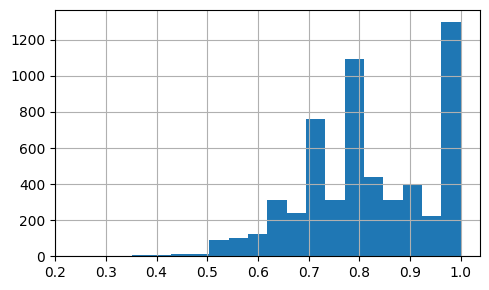

In [40]:
# histograma para checar distribuição dos valores
df_todos["score"].hist(bins=20, figsize=(5,3))
plt.tight_layout()
plt.show()

O histograma mostra que as pontuações estão distribuidas majoritariamente em valores maiores. Com isso, pode ser considerado uma pontuação realmente vantajosa para o processo de desfibragem valores acima de 0.8


Proporção dos valores, garantindo que os valores estão distribuidos, e não concentrados em um só valor de score. Assim, o modelo poderá aprender com cenários diversos.
  

### Distribuição da variavel layers

In [41]:
df_todos["layers"].value_counts()

,count
layers,
mono-layered,4944
multi-layered,801


### Distribuição da variavel "total_findings"

In [42]:
df_todos["total_findings"].describe()

,total_findings
count,5745.000000
mean,2.515753
std,3.038484
min,0.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,32.000000


<Axes: >

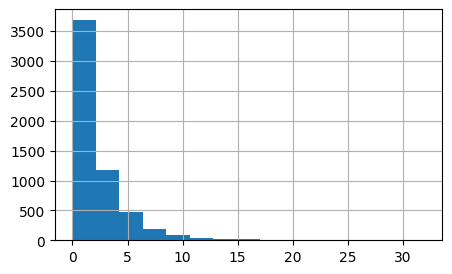

In [43]:
df_todos["total_findings"].hist(bins=15, figsize=(5,3))

### Balanceamento dos valores das fibras


In [44]:
df_todos["fb1_name"].value_counts()

,count
fb1_name,
cotton,2337
polyester,1590
polyamide,461
viscose,333
wool,303
acrylic,149
flax,47
alpaca_llama_cashmere_etc,44
lyocell,37


### Relação entre as variaveis layers e score

In [45]:
df_todos.groupby("layers")["score"].mean()

,score
layers,
mono-layered,0.843370
multi-layered,0.655824


## Síntese

- Apesar do target não estar balanceado no seu sentido tradicional, sua distribuição apresenta concentração entre 0.6 e 1.0, com poucas peças de score abaixo de 0.5. Isso indica que peças com score entre 0.6 e 0.8 devem ser avaliadas com mais cautela em cada caso se realmente são viáveis.

- Os valores ausentes identificados (2 casos em 'layers' no RMM, 1 caso em 'layers' no PCTWM, e 1 linha completa com dados ausentes no subconjunto usado no segundo experimento) representam menos de 0,1% da base — foram tratados como erro desprezível, sem impacto relevante na análise.

- As fibras polyurethane, hemp, cupro, polypropylene, ramie, jute, polyethylene, acetate e polyimide aparecem menos de 10 vezes

- A distribuição do score "escalonada" sugerem o uso de modelos baseados em árvores,  pois particionam o espaço de decisão de forma discreta.


# 5. Preparação dos dados e divisão treino/teste

Foi usada a proporção 80/20 para a divisão (80% treino e 20% teste) com seed fixo para garantir sempre o mesmo resultado todas as vezes que for executado.

Essa proporção garante um equilibrio adequado com dados suficientes para treino e ainda um conjunto de teste suficientemente grande, garantindo métricas confiaveis.

O calculo do score(target) é feito antes da divisão do conjunto de treino e de teste, e por isso o modelo não tem acesso e não corre risco de vazamento de dados.

In [53]:
# separação de conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4596, 43)
Teste: (1149, 43)


# 6. Pré-processamento e pipeline

Foram retiradas colunas com informações redundantes e colunas textuais com faixa percentual da quantidade de cada fibra.

Para a variavel binária "layers" foi usada a codificação simples. Para a variavel "category" o one-hot-encoding classico, pois é uma variavel categorica nominal. Já a variavel fibra foi codificada atraves do "MultiLabelBinarizer" pois uma unica peça (linha) pode conter até 5 fibras.

Valores ausentes foram tratados como ausência legitima.

## Encoding

In [47]:
# lista de colunas que não vão fazer parte do modelo
colunas_remover = [
    "ID", "score",
    "fb1_id", "fb2_id", "fb3_id", "fb4_id", "fb5_id",
    "fb1_percentage", "fb2_percentage", "fb3_percentage",
    "fb4_percentage", "fb5_percentage"
]

# determinação de dados de entrada (x) e target (y)
X = df_todos.drop(columns=colunas_remover)
y = df_todos["score"]

In [48]:
# atributo layers mapeado como binário, ou seja, cada linha só pode ser 0 ou 1
X["layers"] = X["layers"].map({"mono-layered": 0, "multi-layered": 1})

In [49]:
# usando o MultiLabelBinarizer para codificar as colunas com nomes das fibras

colunas_nome_fibra = ["fb1_name", "fb2_name", "fb3_name", "fb4_name", "fb5_name"]

lista_fibras = X[colunas_nome_fibra].apply(
    lambda amostra: [fibra for fibra in amostra if pd.notna(fibra)],
    axis=1
)

mlb = MultiLabelBinarizer()
fibras_encoded = mlb.fit_transform(lista_fibras)

df_fibras_encoded = pd.DataFrame(
    fibras_encoded,
    columns=[f"tem_{fibra}" for fibra in mlb.classes_],
    index=X.index
)

X = pd.concat([X.drop(columns=colunas_nome_fibra), df_fibras_encoded], axis=1)

In [50]:
# codificando a coluna category
X = pd.get_dummies(X, columns=["Category"])

In [51]:
print("Formato final de X:", X.shape)
X.head()

Formato final de X: (5745, 43)


,total_findings,layers,tem_acetate,tem_acrylic,tem_alpaca_llama_cashmere_etc,tem_cotton,tem_cupro,tem_elastane,tem_elastodiene,tem_elastomultiester,...,Category_Overcoats and Anoraks,"Category_Shirts, Blouses, Tops",Category_Sportswear and swimwear,Category_Suits and blazers,Category_Sweaters and Cardigans,Category_Sweaters and cardigans,"Category_T-shirts, singlets and vests, hoodies and crewnecks",Category_Trousers and Shorts,Category_Trousers and shorts,"Category_Underwear, socks, night clothes"
0,1,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,2,0,0,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,2,1,0,0,0,1,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
4,2,1,0,0,0,1,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False


In [52]:
# Conferência do tipo dos valores
X.dtypes.value_counts()

,count
int64,26
bool,17


# 7. Baseline e modelos candidatos

**Regressão Linear**

Escolhida como baseline devido a criação do score ter sido feito a partir de uma fórmula, esperando-se assim que a regressao linear ja aprendesse boa parte do padrão (o que foi confirmado com R² ).

<br>

**Random Forest**

Escolhido como primeiro modelo por combinar multiplas arvores de decisao, e por lidar de forma natural com relações não lineares e interações entre variaveis.


# 8. Treinamento e avaliação inicial

## Regressão Linear

In [55]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

pred_linear = modelo_linear.predict(X_test)

mae_linear = mean_absolute_error(y_test, pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, pred_linear))
r2_linear = r2_score(y_test, pred_linear)

print("=== Regressão Linear (baseline) ===")
print(f"MAE:  {mae_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²:   {r2_linear:.4f}")

=== Regressão Linear (baseline) ===
MAE:  0.0236
RMSE: 0.0287
R²:   0.9484


## Random Forest

In [56]:

modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("=== Random Forest ===")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

=== Random Forest ===
MAE:  0.0083
RMSE: 0.0244
R²:   0.9629



## XGBoost

In [57]:
modelo_xgb = XGBRegressor(random_state=42)
modelo_xgb.fit(X_train, y_train)

pred_xgb = modelo_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("=== XGBoost ===")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")

=== XGBoost ===
MAE:  0.0071
RMSE: 0.0165
R²:   0.9830


### Análise dos resultados iniciais

In [58]:
resultados = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Random Forest", "XGBoost"],
    "MAE": [mae_linear, mae_rf, mae_xgb],
    "RMSE": [rmse_linear, rmse_rf, rmse_xgb],
    "R²": [r2_linear, r2_rf, r2_xgb]
})

resultados

,Modelo,MAE,RMSE,R²
0,Regressão Linear,0.023605,0.028738,0.948404
1,Random Forest,0.008333,0.024376,0.962879
2,XGBoost,0.007140,0.016506,0.982979


In [59]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Melhores parâmetros:", grid_xgb.best_params_)

# avalia o melhor modelo encontrado, no conjunto de teste
melhor_xgb = grid_xgb.best_estimator_
pred_xgb_tuned = melhor_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, pred_xgb_tuned)

print("=== XGBoost (com tuning) ===")
print(f"MAE:  {mae_xgb_tuned:.4f}")
print(f"RMSE: {rmse_xgb_tuned:.4f}")
print(f"R²:   {r2_xgb_tuned:.4f}")

Melhores parâmetros: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
=== XGBoost (com tuning) ===
MAE:  0.0068
RMSE: 0.0159
R²:   0.9841


In [60]:
resultados_final = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Random Forest", "XGBoost", "XGBoost (tuned)"],
    "MAE": [mae_linear, mae_rf, mae_xgb, mae_xgb_tuned],
    "RMSE": [rmse_linear, rmse_rf, rmse_xgb, rmse_xgb_tuned],
    "R²": [r2_linear, r2_rf, r2_xgb, r2_xgb_tuned]
})

resultados_final

,Modelo,MAE,RMSE,R²
0,Regressão Linear,0.023605,0.028738,0.948404
1,Random Forest,0.008333,0.024376,0.962879
2,XGBoost,0.007140,0.016506,0.982979
3,XGBoost (tuned),0.006766,0.015939,0.984127


O XGBoost apresentou o melhor desempenho nas 3 métricas de avaliação, porém as 3 métricas tiveram um vom resultado.

# Segundo experimento

Nesse segundo experimento o objetivo foi entender a resposta do modelo apenas com variaveis visuais, em caso da peça não ter etiqueta.

In [61]:
print(pctwm.shape)
print("Total Metal Finding Types" in pctwm.columns)

(1249, 490)
True


In [62]:
# subconjunto PCTWM dentro do df_todos
df_pctwm_score = df_todos[df_todos["ID"].str.startswith("PC")].reset_index(drop=True)

# Seleciona apenas as colunas visuais do dataset original
colunas_visuais = [
    "Article Category General",
    "Article Category Detail",
    "Total Metal Finding Types",
    "Total plastic Finding Types",
    "Total Fabric Finding Types",
    "Total Other Finding Types"
]

df_visuais = pctwm[colunas_visuais].reset_index(drop=True)

# 3. Junta ID + score (do df_todos) com as colunas visuais (do pctwm original)
df_experimento2 = pd.concat([df_pctwm_score[["ID", "score"]], df_visuais], axis=1)

df_experimento2.head()

,ID,score,Article Category General,Article Category Detail,Total Metal Finding Types,Total plastic Finding Types,Total Fabric Finding Types,Total Other Finding Types
0,PC0001,0.8975,Accessories,Hats and Headwear,0.0,1.0,0.0,0.0
1,PC0002,1.0000,Accessories,Small Accessories,0.0,0.0,0.0,0.0
2,PC0003,1.0000,Accessories,Small Accessories,0.0,0.0,0.0,0.0
3,PC0004,1.0000,Accessories,Medium Accessories,0.0,0.0,0.0,0.0
4,PC0005,1.0000,Accessories,Hats and Headwear,0.0,0.0,0.0,0.0


In [63]:
# Verifica NaN antes de seguir
print(df_experimento2.isna().sum())

ID                             0
score                          0
Article Category General       1
Article Category Detail        1
Total Metal Finding Types      1
Total plastic Finding Types    1
Total Fabric Finding Types     1
Total Other Finding Types      1
dtype: int64


In [64]:
df_experimento2 = df_experimento2.dropna().reset_index(drop=True)

print(df_experimento2.shape)
print(df_experimento2.isna().sum())

(1248, 8)
ID                             0
score                          0
Article Category General       0
Article Category Detail        0
Total Metal Finding Types      0
Total plastic Finding Types    0
Total Fabric Finding Types     0
Total Other Finding Types      0
dtype: int64


In [65]:
X_exp2 = df_experimento2.drop(columns=["ID", "score"])
y_exp2 = df_experimento2["score"]

X_exp2 = pd.get_dummies(X_exp2, columns=["Article Category General", "Article Category Detail"])

print(X_exp2.shape)
X_exp2.dtypes.value_counts()

(1248, 36)


,count
bool,32
float64,4


In [66]:
colunas_findings_visuais = [
    "Total Metal Finding Types", "Total plastic Finding Types",
    "Total Fabric Finding Types", "Total Other Finding Types"
]
X_exp2[colunas_findings_visuais] = X_exp2[colunas_findings_visuais].astype(int)

In [67]:
from sklearn.model_selection import train_test_split

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(
    X_exp2, y_exp2,
    test_size=0.2,
    random_state=42
)

print(X_train_exp2.shape, X_test_exp2.shape)

(998, 36) (250, 36)


In [68]:
# Regressão Linear
modelo_linear_exp2 = LinearRegression()
modelo_linear_exp2.fit(X_train_exp2, y_train_exp2)
pred_linear_exp2 = modelo_linear_exp2.predict(X_test_exp2)

# Random Forest
modelo_rf_exp2 = RandomForestRegressor(random_state=42)
modelo_rf_exp2.fit(X_train_exp2, y_train_exp2)
pred_rf_exp2 = modelo_rf_exp2.predict(X_test_exp2)

# XGBoost
modelo_xgb_exp2 = XGBRegressor(random_state=42)
modelo_xgb_exp2.fit(X_train_exp2, y_train_exp2)
pred_xgb_exp2 = modelo_xgb_exp2.predict(X_test_exp2)

# Métricas
resultados_exp2 = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test_exp2, pred_linear_exp2),
        mean_absolute_error(y_test_exp2, pred_rf_exp2),
        mean_absolute_error(y_test_exp2, pred_xgb_exp2),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_exp2, pred_linear_exp2)),
        np.sqrt(mean_squared_error(y_test_exp2, pred_rf_exp2)),
        np.sqrt(mean_squared_error(y_test_exp2, pred_xgb_exp2)),
    ],
    "R²": [
        r2_score(y_test_exp2, pred_linear_exp2),
        r2_score(y_test_exp2, pred_rf_exp2),
        r2_score(y_test_exp2, pred_xgb_exp2),
    ]
})

resultados_exp2

,Modelo,MAE,RMSE,R²
0,Regressão Linear,0.099649,0.112967,0.061013
1,Random Forest,0.102638,0.119562,-0.051828
2,XGBoost,0.102143,0.121202,-0.080874


# Conclusão

Os resultados são consistentes com a hipótese inicial. O modelo aprendeu sobre o padrão de reciclabilidade a partir dos atributos apresentados.

Já no segundo experimento obteve um resultado inferior, mostrando a importância das informações de composição para essa decisão.

Para estudos futuros podem ser exploradas outras caracteristicas de outros descartes, e outros processos de reciclagem.


### Referências

FATALLA, Fábio Campos; GASI, Fernando; SANCHES, Regina Aparecida. Sustentabilidade e reciclagem de produtos têxteis: fibras, fios, tecidos e malhas. **Projeção e Docência**, v. 17, n. 2, e2852, 2026. DOI: https://doi.org/10.54899/rpd.v17n2-2852.
<br>
<br>
LOGAN, Heather Margaret; SØNDERGAARD, Maggie Ziggie; ROSSI, Valentina; HANSEN, Kamilla Kastrup; DAMGAARD, Anders. Nordic textile anatomy database: composition of garments available in the nordic retail mass market and post-consumer textile waste market. **Data in Brief**, v. 60, 111512, 2025. DOI: https://doi.org/10.1016/j.dib.2025.111512.
<br>
<br>
ASSOCIAÇÃO BRASILEIRA DA INDÚSTRIA TÊXTIL E DE CONFECÇÃO (ABIT); GREENHUB. Guia sobre Reciclagem Têxtil. Programa Moda.Ind-SP. São Paulo, 2024. Disponível em: https://s3.sa-east-1.amazonaws.com/abit-files.abit.org.br/site/links_site/2024/guia_reciclagem/Guia+sobre+Reciclagem+T%C3%AAxtil.pdf.
<br>
<br>
UNIÃO EUROPEIA. Regulamento (UE) nº 1007/2011 do Parlamento Europeu e do Conselho, de 27 de setembro de 2011, relativo às denominações das fibras têxteis. **Jornal Oficial da União Europeia**, L 272, 18 out. 2011.